# Statistical Linear Regression

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
x = np.array([10, 8, 14, 12, 19, 26, 28, 29])
y = np.array([40, 33, 59, 65, 81, 72, 79, 87])

In [3]:
x

array([10,  8, 14, 12, 19, 26, 28, 29])

In [4]:
y

array([40, 33, 59, 65, 81, 72, 79, 87])

In [5]:
len(x)

8

In [6]:
len(y)

8

Define Linear Regression Model

In [7]:
def linear_regression(x: np.array, y: np.array) -> tuple[np.float64, np.float64]:
    
    (x_mean, y_mean) = (x.mean(), y.mean())
    
    # theta_1 -> slope
    theta_1_numerator = ((x - x_mean) * (y - y_mean)).sum()
    theta_1_denominator = ((x - x_mean) ** 2).sum()
    theta_1 = theta_1_numerator / theta_1_denominator
    
    # theta_0 -> y-intercept
    theta_0 = y_mean - (theta_1 * x_mean)
    
    return (theta_0, theta_1)

In [8]:
(theta_0, theta_1) = linear_regression(x, y)
print(f'{theta_0 = }, {theta_1 = }')

theta_0 = 28.14556331006979, theta_1 = 1.992023928215354


In [9]:
x_new = np.linspace(0, 30, 50)

# y = c + mx
y_pred = theta_0 + theta_1 * x_new
y_pred

array([28.14556331, 29.3651698 , 30.58477628, 31.80438277, 33.02398926,
       34.24359574, 35.46320223, 36.68280872, 37.9024152 , 39.12202169,
       40.34162818, 41.56123466, 42.78084115, 44.00044764, 45.22005412,
       46.43966061, 47.6592671 , 48.87887358, 50.09848007, 51.31808656,
       52.53769304, 53.75729953, 54.97690602, 56.1965125 , 57.41611899,
       58.63572548, 59.85533196, 61.07493845, 62.29454494, 63.51415142,
       64.73375791, 65.9533644 , 67.17297088, 68.39257737, 69.61218386,
       70.83179034, 72.05139683, 73.27100332, 74.4906098 , 75.71021629,
       76.92982278, 78.14942926, 79.36903575, 80.58864224, 81.80824872,
       83.02785521, 84.2474617 , 85.46706818, 86.68667467, 87.90628116])

[]

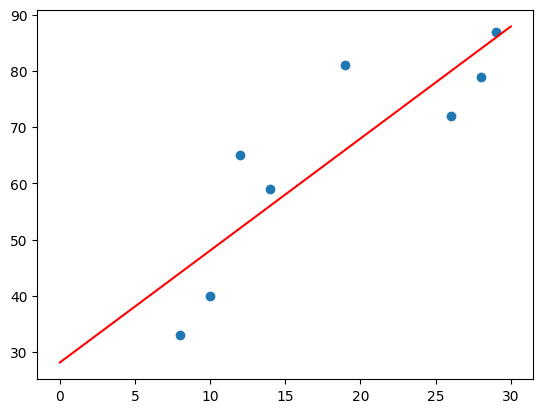

In [10]:
plt.plot(x_new, y_pred, 'r')
plt.scatter(x, y)
plt.plot()

Define RMSE(Rooted Mean Squared Error)

In [11]:
def predict(theta_0: np.float64, theta_1: np.float64, x: np.float64) -> np.float64:
    '''
    	y = mx + c
    '''
    return (theta_1 * x) + theta_0

In [12]:
y_pred = predict(theta_0, theta_1, x)
y_pred

array([48.06580259, 44.08175474, 56.03389831, 52.04985045, 65.99401795,
       79.93818544, 83.9222333 , 85.91425723])

In [13]:
def RMSE(y_true: np.float64, y_pred: np.float64) -> np.float64:
	n = len(y_true)
	return np.sqrt(((y_true - y_pred) ** 2).sum() / n)

In [14]:
RMSE(y, y_pred)

9.20575971683531

# Gradient Descent Linear Regression

In [15]:
x = np.array([10, 8, 14, 12, 19, 26, 28, 29]).reshape(-1, 1)
y = np.array([40, 33, 59, 65, 81, 72, 79, 87]).reshape(-1, 1)

In [16]:
x

array([[10],
       [ 8],
       [14],
       [12],
       [19],
       [26],
       [28],
       [29]])

In [17]:
y

array([[40],
       [33],
       [59],
       [65],
       [81],
       [72],
       [79],
       [87]])

In [18]:
# Initialize all parameters
(theta_0, theta_1) = (0, 0)

# Hyperparameters
learning_rate = 1e-3
n_iter = 1000

n_samples = len(x)

Gradient Descent Loop

In [19]:
pbar = tqdm(range(n_iter))

for _ in pbar:
    
	predictions = predict(theta_0, theta_1, x)
	err = predictions - y

	tmp_slope = learning_rate * (1 / n_samples) * np.sum(err * x)
	tmp_y_intercept = learning_rate * (1 / n_samples) * np.sum(err)

	theta_1 -= tmp_slope
	theta_0 -= tmp_y_intercept
 
	current_rmse = np.sqrt(np.mean(err ** 2))
	pbar.set_postfix({'RMSE': f'{current_rmse:.4f}'})
 
print(f'{theta_0 = }, {theta_1 = }')

100%|██████████| 1000/1000 [00:00<00:00, 1492.07it/s, RMSE=13.2387]

theta_0 = 4.244684034312252, theta_1 = 3.094652694717257


# Linear Regression with SKLearn

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
x = np.array([10, 8, 14, 12, 19, 26, 28, 29]).reshape(-1, 1)
y = np.array([40, 33, 59, 65, 81, 72, 79, 87]).reshape(-1, 1)

In [ ]:
model.fit(x, y)

LinearRegression()

In [ ]:
print(f'y = {model.coef_[0][0]}x + ({model.intercept_[0]})')

y = 1.9920239282153545x + (28.145563310069782)


# Multi-linear Regression

In [ ]:
x_1 = np.array([10, 8, 14, 12, 19, 26, 28, 29]).reshape(-1, 1)
x_2 = np.array([3, 2, 5, 5, 7, 8, 8, 9]).reshape(-1, 1)
y = np.array([40, 33, 59, 65, 81, 72, 79, 87]).reshape(-1, 1)

In [ ]:
x = np.insert(x_1, [1], x_2, axis=1)
x

array([[10,  3],
       [ 8,  2],
       [14,  5],
       [12,  5],
       [19,  7],
       [26,  8],
       [28,  8],
       [29,  9]])

In [ ]:
model = LinearRegression()
model.fit(x, y)

LinearRegression()

In [ ]:
print(model.coef_)
print(model.intercept_)

[[-1.84647119 13.34492412]]
[19.7966701]


In [ ]:
def predict_multilinear(model: LinearRegression, x_1: np.float64, x_2: np.float64) -> np.float64:
    return sum([m * x for m, x in zip(model.coef_[0], [x_1, x_2])]) + model.intercept_

In [ ]:
predict_multilinear(model, x_1, x_2)

array([[41.36673051],
       [31.71474878],
       [60.67069397],
       [64.36363636],
       [78.12818624],
       [78.54781199],
       [74.8548696 ],
       [86.35332253]])

In [ ]:
RMSE(y, [e[0] for e in predict_multilinear(model, x_1, x_2)])

72.5297355988832